In [21]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [22]:
def f(t,A,B,tau):
    return A + B * np.exp(-t/tau)

TransferFunctionContinuous(
array([3.55e-01, 1.75e+06]),
array([1.e+00, 5.e+06]),
dt: None
)
7200
[3.5e-01 5.0e-03 2.0e-07]


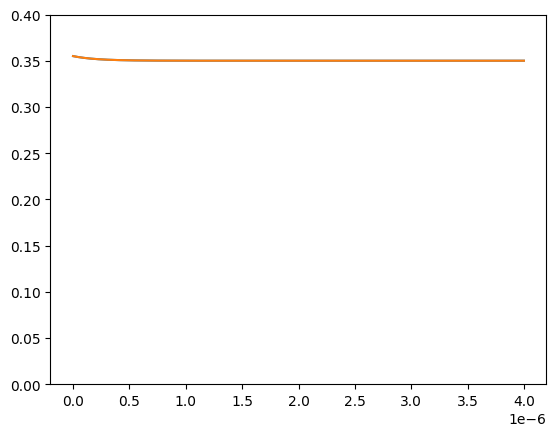

(array([ 2.81695644, -2.80914241]), array([ 1.        , -0.99726509]))
1.0000000028186462


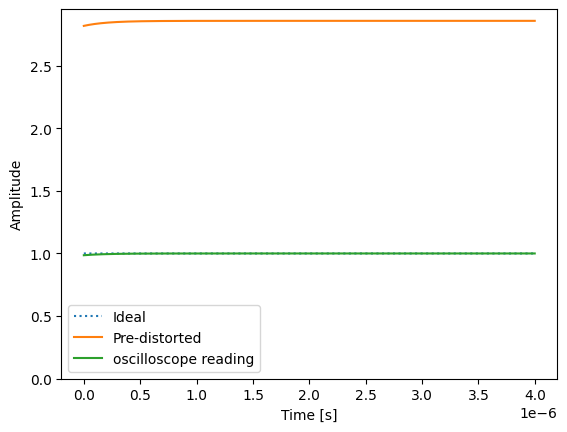

In [23]:

A = 350*1e-3 # mV
B = 5*1e-3 # mV
tau = 200e-9 # ns

fs = 1.8e9 #Hz
Ts = 1/fs
#System Filter is just 1/Inverse

t = np.arange(0,4000e-9, Ts)

system_filter = sp.signal.lti([tau*(A+B), A],[tau,1])
print(system_filter)
print(len(t))
t,y = sp.signal.step(system_filter,T=t)
plt.plot(t, y)
plt.ylim(0,.4)

start=1
stop=-1

fit_params, _ = sp.optimize.curve_fit(f,t[start:stop], y[start:stop],p0=(100e-3,100e-3,100e-9))

A,B,tau = fit_params
print(fit_params)
plt.plot(t,f(t,A,B,tau))
plt.show()
# Inverse bilinear
inverse_IIR = sp.signal.bilinear(b=[tau,1],a=[tau*(A+B), A],fs=fs)

print(inverse_IIR)
inverse_IIR_LTI = sp.signal.lti(inverse_IIR[0], inverse_IIR[1])

ideal = sp.signal.gaussian(len(t), std=1000)
ideal = 1 * np.ones_like(t)
ideal = sp.ndimage.gaussian_filter1d(ideal,sigma=1)

pre_distorted = sp.signal.lfilter(inverse_IIR[0], inverse_IIR[1], x=ideal)

# raw_oscilloscope[0] = 0
# raw_oscilloscope[-1] = 0
pre_distorted_measured = sp.signal.lfilter(a=[tau,1][::-1],b=[tau*(A+B), A][::-1], x=pre_distorted)

print(pre_distorted_measured[-1])
plt.plot(t, ideal,':',label='Ideal')
plt.plot(t,pre_distorted, label='Pre-distorted')

plt.plot(t,pre_distorted_measured,"-", label='oscilloscope reading')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend(loc='best')
plt.ylim(0,)

plt.show()

(900, 1000)


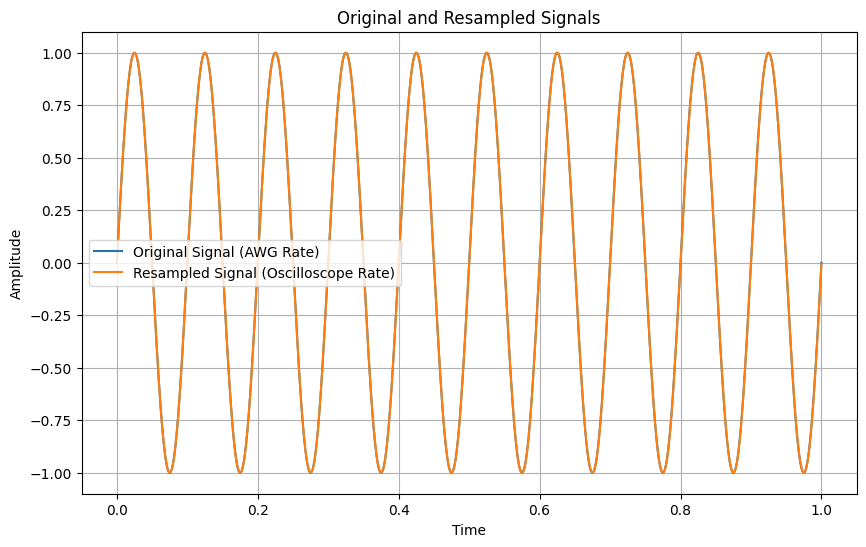

In [202]:
import numpy as np
import matplotlib.pyplot as plt

# Function to construct the resampling matrix
def construct_resampling_matrix(N_awg, N_oscilloscope):
    H_res = np.zeros((N_oscilloscope, N_awg))
    
    # Calculate the interpolation factor
    factor = N_awg / N_oscilloscope
    
    for i in range(N_oscilloscope):
        # Determine the indices in the input signal for interpolation
        idx_low = int(np.floor(i * factor))
        idx_high = min(idx_low + 1, N_awg - 1)
        
        # Linear interpolation weights
        weight_high = i * factor - idx_low
        weight_low = 1 - weight_high
        
        # Fill in the resampling matrix
        H_res[i, idx_low] = weight_low
        H_res[i, idx_high] = weight_high
    
    return H_res

# Generate a sinusoidal signal sampled at a higher rate (simulating AWG rate)
N_awg = 1000  # Number of samples at AWG rate
t_awg = np.linspace(0, 1, N_awg)  # Time vector for AWG signal
f_signal = 10  # Frequency of the sinusoidal signal
signal_awg = np.sin(2 * np.pi * f_signal * t_awg)  # Sinusoidal signal at AWG rate

# Resample the signal to a lower rate (simulating oscilloscope rate)
N_oscilloscope = 900  # Number of samples at oscilloscope rate
H_resampling = construct_resampling_matrix(N_awg, N_oscilloscope)
print(H_resampling.shape)
signal_oscilloscope = np.matmul(H_resampling, signal_awg)  # Resampled signal at oscilloscope rate

# Plot the original and resampled signals
plt.figure(figsize=(10, 6))
plt.plot(t_awg, signal_awg, label='Original Signal (AWG Rate)')
plt.plot(np.linspace(0, 1, N_oscilloscope), signal_oscilloscope, label='Resampled Signal (Oscilloscope Rate)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Original and Resampled Signals')
plt.legend()
plt.grid(True)
plt.show()


In [203]:
N = N_awg
M = N_oscilloscope

x = np.ones(N)
y = np.ones(M) 

D = np.zeros((N-1, N))

# Fill diagonal with 1s
np.fill_diagonal(D, 1)

# Fill above diagonal with -1s
for i in range(N-1):
    D[i, i+1] = -1

np.power(D@x, 2).sum()

0.0

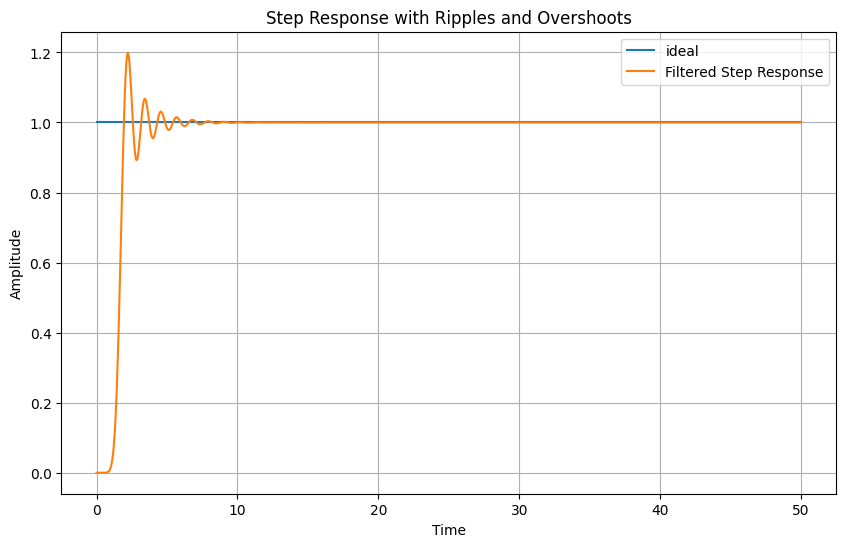

899


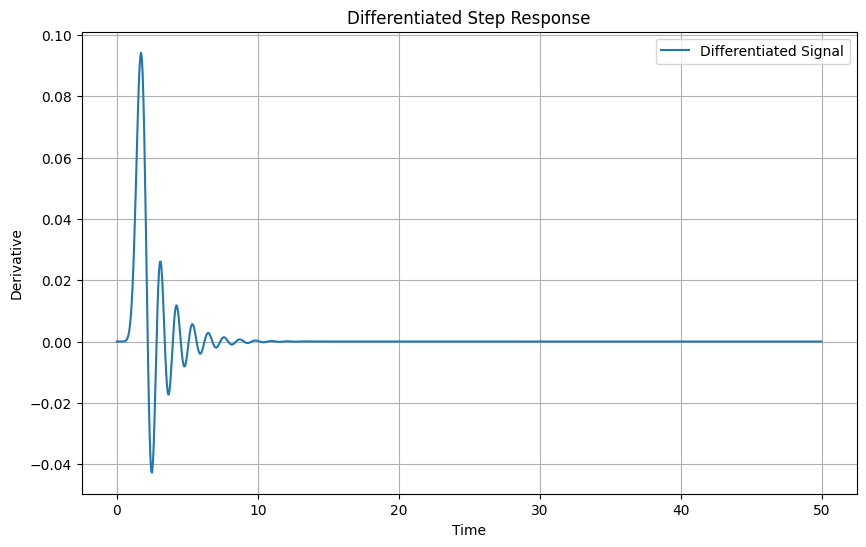

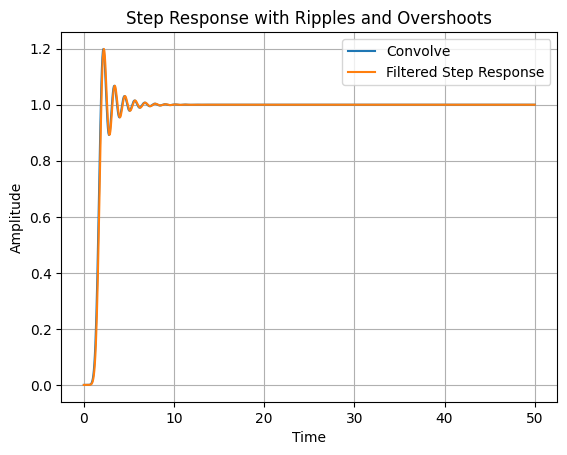

In [204]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Define parameters
num_taps_fir = 5  # Number of taps for the FIR filter
num_taps_iir = 14   # Number of taps for the IIR filter

# Generate step input
t = np.linspace(0, 50, M)
step_input = np.ones_like(t)

# Design IIR filter (for generating ripples and overshoots)
iir_b, iir_a = signal.butter(num_taps_iir, 0.1)
output_iir = signal.lfilter(iir_b, iir_a, step_input)

# # Design FIR filter (to correct imperfections)
fir_b = signal.firls(num_taps_fir, [0, 0.1, 0.2, 0.5], [0, 1, 0, 0])
# output_fir = signal.lfilter(fir_b, 1, output_iir)

# Plot the step response
plt.figure(figsize=(10, 6))
plt.plot(t, step_input, label='ideal')
plt.plot(t, output_iir, label='Filtered Step Response')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Step Response with Ripples and Overshoots')
plt.grid(True)
plt.legend()
plt.show()

h = np.diff(output_iir)
print(len(h))
# Plot the differentiated signal
plt.figure(figsize=(10, 6))
plt.plot(t[:-1], h, label='Differentiated Signal')
plt.xlabel('Time')
plt.ylabel('Derivative')
plt.title('Differentiated Step Response')
plt.grid(True)
plt.legend()
plt.show()

Himp = sp.linalg.convolution_matrix(h, n = len(x))[:M, :M]

y = Himp @ H_resampling @ x
# y = np.convolve(h, x)[:M]

plt.plot(t,y, label='Convolve')
plt.plot(t, output_iir, label='Filtered Step Response')

plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Step Response with Ripples and Overshoots')
plt.grid(True)
plt.legend()
plt.show()


In [205]:
import torch

y = torch.Tensor(output_iir)

x = torch.zeros_like(torch.Tensor(x), requires_grad=True)

D = torch.Tensor(D)
Himp = torch.Tensor(Himp)
Hres = torch.Tensor(H_resampling)

loss_function = torch.nn.MSELoss()
optimizer = torch.optim.Adam([{'params': x, 'lr': 1e-3}])

alpha = 1.0

for epoch in range(50000):

    y_pred = torch.mm(
        Himp,
        torch.mm(
            Hres, x.unsqueeze(1)
        )
    ).squeeze(1)

    R = torch.pow(
        torch.mm(
            D, x.unsqueeze(1)
        ), 2
    ).sum()

    loss = loss_function(y, y_pred) + alpha * R
    if epoch % 10000 == 0: 
        print(loss)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()



tensor(0.9675, grad_fn=<AddBackward0>)
tensor(0.0001, grad_fn=<AddBackward0>)
tensor(0.0001, grad_fn=<AddBackward0>)
tensor(0.0001, grad_fn=<AddBackward0>)
tensor(0.0001, grad_fn=<AddBackward0>)


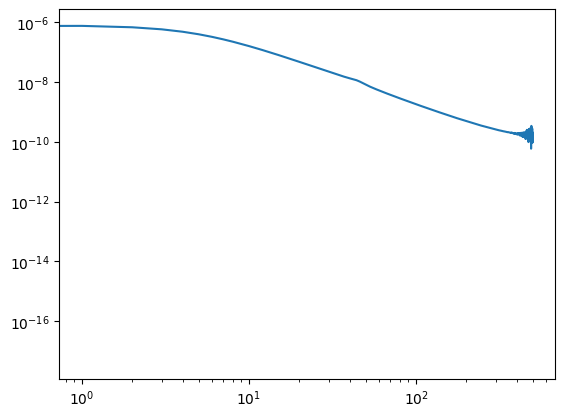

Filter length:  5.555555555555555e-07


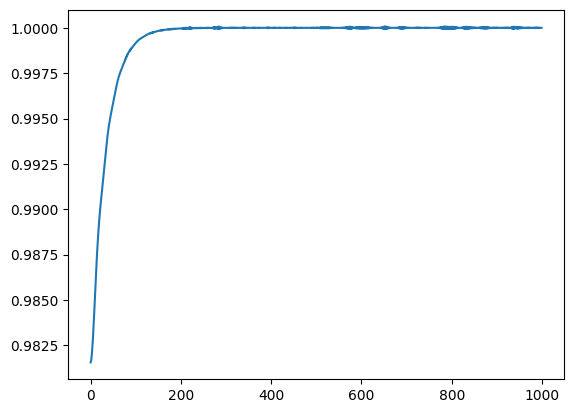

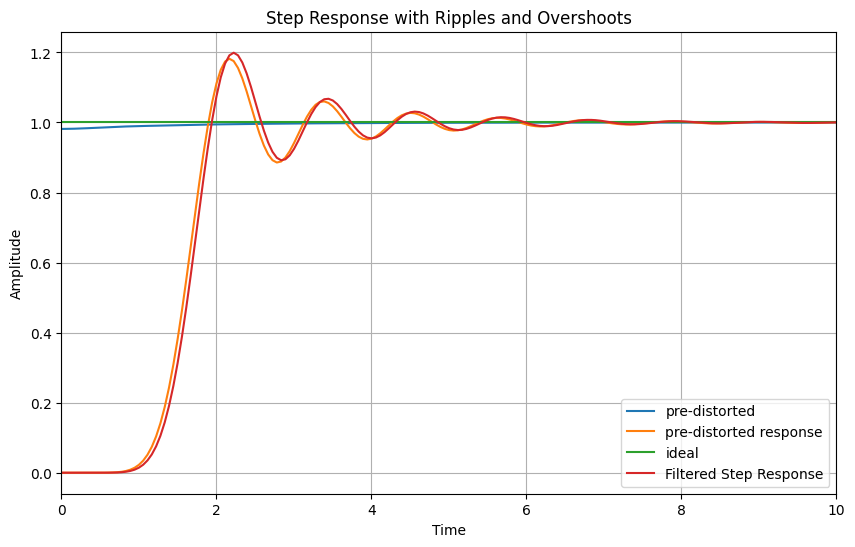

In [206]:
hinv = x.detach().numpy()

# f, Pxx = sp.signal.periodogram(h, N_awg)
f, Pxx = sp.signal.periodogram(hinv, N_awg)
plt.loglog(
    f, Pxx
)
plt.show()

print("Filter length: ", len(hinv)/(1.8e9))
plt.plot(hinv)

hinv_fir = Himp @ Hres @ (hinv * np.ones(N))

plt.figure(figsize=(10, 6))
plt.plot(t, H_resampling @ (hinv * np.ones(N)), label='pre-distorted')
plt.plot(t, hinv_fir, label='pre-distorted response')
plt.plot(t, step_input, label='ideal')
plt.plot(t, output_iir, label='Filtered Step Response')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Step Response with Ripples and Overshoots')
plt.grid(True)
plt.xlim(0,10)
plt.legend()
plt.show()